In [2]:
from dotenv import load_dotenv
import os

load_dotenv()  # take environment variables from .env.

if os.environ['OPENAI_API_KEY']:
    print("Open API Key is set")
else:
    raise ValueError("OPENAI_API_KEY is not set in the environment variables.")

Open API Key is set


In [3]:
# taken from https://docs.langchain.com/oss/python/integrations/chat/openai - instantiation section
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5.4-nano-2026-03-17")
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain-openai': '1.3.3'}}, output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x7fa239f292b0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7fa239d125a0>, root_client=<openai.OpenAI object at 0x7fa23a0257f0>, root_async_client=<openai.AsyncOpenAI object at 0x7fa239bf22d0>, model_name='gpt-5.4-nano-2026-03-17', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_proxy=None, stream_usage=True, stream_chunk_timeout=120.0)

In [5]:
llm.invoke("I want to know the meaning of life")

AIMessage(content='That’s a huge question—and different people mean different things by “meaning.”\n\nHere are a few common ways people approach it:\n\n- **Purpose through connection:** Loving others, building relationships, being part of something bigger than yourself.\n- **Purpose through contribution:** Helping, creating, teaching, solving problems—leaving the world better in some concrete way.\n- **Purpose through growth:** Learning, becoming wiser, becoming more honest/compassionate/brave.\n- **Purpose as lived experience:** Finding meaning in moments—music, nature, art, play, faith, wonder—rather than a single grand “answer.”\n- **Purpose as choice:** If there’s no built-in meaning, you create it through what you value and what you commit to.\n\nIf you want something more personal: when you ask this, do you feel **curious and hopeful**, or more like **empty/overwhelmed**? And what’s been on your mind lately—any particular loss, stress, or change?', additional_kwargs={'refusal': N

### **Step-1: Define schema of state**

In [4]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    name: str
    message: str

### **Step-2: Create the Node function**

In [10]:
# This is a simple function that pass current name and current message to LLM, and returns the response from open API.
def welcome(state:graph_schema) -> graph_schema:
    curr_name = state['name']
    curr_message = state['message']

    response = llm.invoke(f"My name is {curr_name}. {curr_message}").content

    state['message'] = f"Your message was {curr_message}. Here's my response: {response}"

    return state

### **Step-3: Create The State Graph**

In [14]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)
graph.add_node("welcome", welcome)

# Create edges
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)


### **Step-4: Compile the Graph**

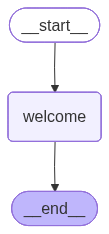

In [15]:
from IPython.display import Image, display

first_graph = graph.compile()

# You can see errors with the following command
Image(first_graph.get_graph().draw_mermaid_png())

# You can use the below command to see the graph without error
# print(first_graph.get_graph().draw_mermaid())

### **Step-5: Run The Graph**

In [16]:
first_graph.invoke({"name": "Arya", "message":"How are you?"})

{'name': 'Arya',
 'message': "Your message was How are you?. Here's my response: Hi Arya! I’m doing well—thanks for asking 😊 How are you today?"}